# Model Selection and Improvement

This notebook builds upon the baseline by:
- Removing leaky features (`Customers`, `Unnamed: 0`)
- Adding engineered features (time-based, promo, competition, etc.)
- Comparing multiple models: LightGBM, XGBoost, CatBoost
- Tuning the best model using Optuna
- Visualizing feature importance of the final model

## 1. Imports and Settings

In [21]:
import sys

print(sys.executable)

/Users/a.rukavitsyna/PycharmProjects/rossmann-sales-forecast/.venv/bin/python


In [22]:
import sys

!{sys.executable} -m pip install lightgbm xgboost catboost optuna --quiet

import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from optuna.pruners import MedianPruner

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 2. Load Data

In [23]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

train = pd.read_csv(DATA_DIR / "train_processed.csv", low_memory=False, parse_dates=["Date"])
test = pd.read_csv(DATA_DIR / "test_processed.csv", low_memory=False, parse_dates=["Date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1017209, 18)
Test shape: (41088, 16)


In [24]:
train.head(10)

,Unnamed: 0,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,is_Promo2_known,months_since_Promo2,is_competition_open_known,months_since_competition_open
0,0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,0,0,0.00,1,24105.0
1,1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,1,1,24123.25,1,24095.0
2,2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,1,1,24135.50,1,24084.0
3,3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,0,0,0.00,1,24117.0
4,4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,0,0,0.00,1,24184.0
5,5,6,5,2015-07-31,5651,589,1,1,0,1,a,a,310.0,0,0,0.00,1,24168.0
6,6,7,5,2015-07-31,15344,1414,1,1,0,1,a,c,24000.0,0,0,0.00,1,24160.0
7,7,8,5,2015-07-31,8492,833,1,1,0,1,a,a,7520.0,0,0,0.00,1,24178.0
8,8,9,5,2015-07-31,8565,687,1,1,0,1,a,c,2030.0,0,0,0.00,1,24008.0
9,9,10,5,2015-07-31,7185,681,1,1,0,1,a,a,3160.0,0,0,0.00,1,24117.0


In [25]:
test.head(10)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,is_Promo2_known,months_since_Promo2,is_competition_open_known,months_since_competition_open
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,0,0,0.00,1,24105.0
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,1,1,24135.50,1,24084.0
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,0,0,0.00,1,24160.0
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,0,0,0.00,1,24178.0
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,0,0,0.00,1,24008.0
5,6,10,4,2015-09-17,1.0,1,0,0,a,a,3160.0,0,0,0.00,1,24117.0
6,7,11,4,2015-09-17,1.0,1,0,0,a,c,960.0,1,1,24144.25,1,24143.0
7,8,12,4,2015-09-17,1.0,1,0,0,a,c,1070.0,1,1,24123.25,0,0.0
8,9,13,4,2015-09-17,1.0,1,0,0,d,a,310.0,1,1,24119.25,0,0.0
9,10,14,4,2015-09-17,1.0,1,0,0,a,a,1300.0,1,1,24142.00,1,24171.0


In [26]:
# Drop unnecessary columns
drop_cols = ['Unnamed: 0', 'Customers']  # 'Unnamed: 0' is index, 'Customers' not in test
train.drop(columns=drop_cols, inplace=True, errors='ignore')
test.drop(columns=[col for col in drop_cols if col in test.columns], inplace=True, errors='ignore')

print("Train columns after dropping:", train.columns.tolist())
print("Test columns after dropping:", test.columns.tolist())

Train columns after dropping: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'is_Promo2_known', 'months_since_Promo2', 'is_competition_open_known', 'months_since_competition_open']
Test columns after dropping: ['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'is_Promo2_known', 'months_since_Promo2', 'is_competition_open_known', 'months_since_competition_open']


## 3.1. Feature Engineering

In [27]:
def add_engineered_features(df):
    """
    Add time-based, promo, competition and interaction features.
    """
    df = df.copy()

    # Already have time features from baseline: Year, Month, Day, WeekOfYear, DayOfYear, IsMonthStart, IsMonthEnd

    # Additional: day of week is already present (DayOfWeek)
    # Add quarter
    df['Quarter'] = df['Date'].dt.quarter

    # Interactions
    df['Promo_DayOfWeek'] = df['Promo'] * df['DayOfWeek']
    df['Promo_StoreType'] = df['Promo'].astype(str) + '_' + df['StoreType'].astype(str)
    df['Promo_Assortment'] = df['Promo'].astype(str) + '_' + df['Assortment'].astype(str)

    # Encode categoricals
    cat_cols = ['StoreType', 'Assortment', 'StateHoliday', 'Promo_StoreType', 'Promo_Assortment']
    for col in cat_cols:
        df[col] = df[col].astype('category')

    return df

In [28]:
train_eng = add_engineered_features(train)
test_eng = add_engineered_features(test)

print("Train engineered shape:", train_eng.shape)
print("Test engineered shape:", test_eng.shape)

Train engineered shape: (1017209, 20)
Test engineered shape: (41088, 20)


In [29]:
train_eng.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,is_Promo2_known,months_since_Promo2,is_competition_open_known,months_since_competition_open,Quarter,Promo_DayOfWeek,Promo_StoreType,Promo_Assortment
0,1,5,2015-07-31,5263,1,1,0,1,c,a,1270.0,0,0,0.00,1,24105.0,3,5,1_c,1_a
1,2,5,2015-07-31,6064,1,1,0,1,a,a,570.0,1,1,24123.25,1,24095.0,3,5,1_a,1_a
2,3,5,2015-07-31,8314,1,1,0,1,a,a,14130.0,1,1,24135.50,1,24084.0,3,5,1_a,1_a
3,4,5,2015-07-31,13995,1,1,0,1,c,c,620.0,0,0,0.00,1,24117.0,3,5,1_c,1_c
4,5,5,2015-07-31,4822,1,1,0,1,a,a,29910.0,0,0,0.00,1,24184.0,3,5,1_a,1_a


In [30]:
test_eng.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,is_Promo2_known,months_since_Promo2,is_competition_open_known,months_since_competition_open,Quarter,Promo_DayOfWeek,Promo_StoreType,Promo_Assortment
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,0,0,0.0,1,24105.0,3,4,1_c,1_a
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,1,1,24135.5,1,24084.0,3,4,1_a,1_a
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,0,0,0.0,1,24160.0,3,4,1_a,1_c
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,0,0,0.0,1,24178.0,3,4,1_a,1_a
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,0,0,0.0,1,24008.0,3,4,1_a,1_c


## 3.2. Calendar features

In [31]:
def add_calendar(df):
    df = df.sort_values('Date').copy()
    df['IsWeekend'] = df['DayOfWeek'].isin([6,7]).astype(int)

    # State holidays (StateHoliday != '0')
    df['is_state_holiday'] = (df['StateHoliday'] != '0').astype(int)
    df['tomorrow_state_holiday'] = df['is_state_holiday'].shift(-1).fillna(0).astype(int)
    df['yesterday_state_holiday'] = df['is_state_holiday'].shift(1).fillna(0).astype(int)

    # School holidays
    df['is_school_holiday'] = df['SchoolHoliday'].astype(int)
    df['tomorrow_school_holiday'] = df['is_school_holiday'].shift(-1).fillna(0).astype(int)
    df['yesterday_school_holiday'] = df['is_school_holiday'].shift(1).fillna(0).astype(int)

    return df

In [32]:
train_eng = add_calendar(train_eng)
test_eng = add_calendar(test_eng)

In [33]:
test_eng.shape

(41088, 27)

In [34]:
test_eng.columns

Index(['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'Promo2', 'is_Promo2_known', 'months_since_Promo2',
       'is_competition_open_known', 'months_since_competition_open', 'Quarter',
       'Promo_DayOfWeek', 'Promo_StoreType', 'Promo_Assortment', 'IsWeekend',
       'is_state_holiday', 'tomorrow_state_holiday', 'yesterday_state_holiday',
       'is_school_holiday', 'tomorrow_school_holiday',
       'yesterday_school_holiday'],
      dtype='str')

In [35]:
train_eng.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'Promo2', 'is_Promo2_known', 'months_since_Promo2',
       'is_competition_open_known', 'months_since_competition_open', 'Quarter',
       'Promo_DayOfWeek', 'Promo_StoreType', 'Promo_Assortment', 'IsWeekend',
       'is_state_holiday', 'tomorrow_state_holiday', 'yesterday_state_holiday',
       'is_school_holiday', 'tomorrow_school_holiday',
       'yesterday_school_holiday'],
      dtype='str')

## 4. Prepare Data for Modeling

In [36]:
# Sort full dataset by date
train_eng = train_eng.sort_values('Date').reset_index(drop=True)

# Time-based split (80% quantile) - on full dataset
split_date = train_eng['Date'].quantile(0.8)

train_part_eng = train_eng[train_eng['Date'] < split_date].copy()
valid_part_eng = train_eng[train_eng['Date'] >= split_date].copy()

# Use filters Open==1 and Sales>0 to work with not-null data only for train data
train_part_eng = train_part_eng[(train_part_eng['Open'] == 1) & (train_part_eng['Sales'] > 0)].copy()

# valid_part_eng is left with all Open==0/1 days
print(f"Train period: {train_part_eng['Date'].min()} to {train_part_eng['Date'].max()}")
print(f"Validation period: {valid_part_eng['Date'].min()} to {valid_part_eng['Date'].max()}")
print(f"Train rows: {len(train_part_eng)}, Validation rows: {len(valid_part_eng)}")
print(f"Validation closed-store rows: {(valid_part_eng['Open'] == 0).sum()}")

Train period: 2013-01-01 00:00:00 to 2015-01-29 00:00:00
Validation period: 2015-01-30 00:00:00 to 2015-07-31 00:00:00
Train rows: 674844, Validation rows: 204045
Validation closed-store rows: 34548


In [37]:
# Compute safe historical aggregates using only train_part_eng (no future/valid data)
train_open_full = train_part_eng[(train_part_eng['Open'] == 1) & (train_part_eng['Sales'] > 0)]

store_mean = train_open_full.groupby('Store')['Sales'].mean().rename('store_mean_sales')
store_dow_mean = train_open_full.groupby(['Store', 'DayOfWeek'])['Sales'].mean().rename('store_dow_mean_sales')

global_mean = train_open_full['Sales'].mean()

train_part_eng = train_part_eng.merge(store_mean, on='Store', how='left')
train_part_eng = train_part_eng.merge(store_dow_mean, on=['Store', 'DayOfWeek'], how='left')

valid_part_eng = valid_part_eng.merge(store_mean, on='Store', how='left')
valid_part_eng = valid_part_eng.merge(store_dow_mean, on=['Store', 'DayOfWeek'], how='left')

test_eng = test_eng.merge(store_mean, on='Store', how='left')
test_eng = test_eng.merge(store_dow_mean, on=['Store', 'DayOfWeek'], how='left')

train_part_eng['store_mean_sales'] = train_part_eng['store_mean_sales'].fillna(global_mean)
train_part_eng['store_dow_mean_sales'] = train_part_eng['store_dow_mean_sales'].fillna(global_mean)
valid_part_eng['store_mean_sales'] = valid_part_eng['store_mean_sales'].fillna(global_mean)
valid_part_eng['store_dow_mean_sales'] = valid_part_eng['store_dow_mean_sales'].fillna(global_mean)
test_eng['store_mean_sales'] = test_eng['store_mean_sales'].fillna(global_mean)
test_eng['store_dow_mean_sales'] = test_eng['store_dow_mean_sales'].fillna(global_mean)

In [38]:
# Define features and target
features_eng = [col for col in train_part_eng.columns if col not in ['Sales', 'Date']]
target = 'Sales'

In [39]:
features_eng

['Store',
 'DayOfWeek',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'Promo2',
 'is_Promo2_known',
 'months_since_Promo2',
 'is_competition_open_known',
 'months_since_competition_open',
 'Quarter',
 'Promo_DayOfWeek',
 'Promo_StoreType',
 'Promo_Assortment',
 'IsWeekend',
 'is_state_holiday',
 'tomorrow_state_holiday',
 'yesterday_state_holiday',
 'is_school_holiday',
 'tomorrow_school_holiday',
 'yesterday_school_holiday',
 'store_mean_sales',
 'store_dow_mean_sales']

In [40]:
X_train_eng = train_part_eng[features_eng].copy()
y_train_eng = train_part_eng[target].copy()
X_valid_eng = valid_part_eng[features_eng].copy()
y_valid_eng = valid_part_eng[target].copy()
X_test_eng = test_eng[features_eng].copy()

In [41]:
# Ensure categorical columns are category dtype
cat_cols_eng = X_train_eng.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols_eng:
    X_train_eng[col] = X_train_eng[col].astype('category')
    X_valid_eng[col] = X_valid_eng[col].astype('category')
    X_test_eng[col] = X_test_eng[col].astype('category')

print("X_train_eng shape:", X_train_eng.shape)
print("X_valid_eng shape:", X_valid_eng.shape)
print("X_test_eng shape:", X_test_eng.shape)

X_train_eng shape: (674844, 27)
X_valid_eng shape: (204045, 27)
X_test_eng shape: (41088, 27)


In [42]:
# Verify Promo dtype and value distribution
print(X_train_eng['Promo'].dtype)
print(X_train_eng['Promo'].value_counts())

int64
Promo
0    374148
1    300696
Name: count, dtype: int64


In [43]:
X_train_eng.dtypes

Store                               int64
DayOfWeek                           int64
Open                                int64
Promo                               int64
StateHoliday                     category
SchoolHoliday                       int64
StoreType                        category
Assortment                       category
CompetitionDistance               float64
Promo2                              int64
is_Promo2_known                     int64
months_since_Promo2               float64
is_competition_open_known           int64
months_since_competition_open     float64
Quarter                             int32
Promo_DayOfWeek                     int64
Promo_StoreType                  category
Promo_Assortment                 category
IsWeekend                           int64
is_state_holiday                    int64
tomorrow_state_holiday              int64
yesterday_state_holiday             int64
is_school_holiday                   int64
tomorrow_school_holiday           

## 5. Define RMSPE Metric and convert target to log scale

In [44]:
def rmspe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

In [46]:
# Log-transform target for training; predictions must be converted back with expm1
mask_valid_open = (valid_part_eng['Open'] == 1).values

y_train_eng_log = np.log1p(y_train_eng)
y_valid_eng_log = np.log1p(y_valid_eng[mask_valid_open])

## 6. Baseline with LightGBM (without Customers)

In [47]:
def rmspe_lgb(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.maximum(np.expm1(y_pred), 0)
    mask = y_true != 0
    score = np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))
    return 'rmspe', score, False

mask_valid_open = (valid_part_eng['Open'] == 1).values

In [49]:
# Train a LightGBM model with default parameters and added eng features.

lgb_base = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_base.fit(
    X_train_eng, y_train_eng_log,
    eval_set=[(X_valid_eng[mask_valid_open], y_valid_eng_log)],
    eval_metric=rmspe_lgb,
    callbacks=[lgb.early_stopping(50)]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's l2: 0.025843	valid_0's rmspe: 0.163825


,num_leaves,64
,learning_rate,0.05
,n_estimators,1000
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000


In [50]:
pred_base = np.zeros(len(X_valid_eng))
pred_base[mask_valid_open] = np.expm1(lgb_base.predict(X_valid_eng[mask_valid_open]))
pred_base = np.maximum(pred_base, 0)

score_base = rmspe(y_valid_eng, pred_base)
print(f"Baseline LightGBM (no Customers) RMSPE for engineered features: {score_base:.6f}")

Baseline LightGBM (no Customers) RMSPE for engineered features: 0.163825


## 7. Model Comparison: LightGBM vs CatBoost

In [51]:
# LightGBM with tuned defaults (using early stopping)
lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_model.fit(
    X_train_eng, y_train_eng_log,
    eval_set=[(X_valid_eng[mask_valid_open], y_valid_eng_log)],
    eval_metric=rmspe_lgb,
    callbacks=[lgb.early_stopping(50)]
)

pred_lgb = np.zeros(len(X_valid_eng))
pred_lgb[mask_valid_open] = np.expm1(lgb_model.predict(X_valid_eng[mask_valid_open]))
pred_lgb = np.maximum(pred_lgb, 0)
score_lgb = rmspe(y_valid_eng, pred_lgb)

print(f"LightGBM with tuned defaults - RMSPE: {score_lgb:.6f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1197]	valid_0's l2: 0.0258162	valid_0's rmspe: 0.163611
LightGBM with tuned defaults - RMSPE: 0.163611


In [52]:
# CatBoost RMSPE metric class
class RMSPEMetric:
    def is_max_optimal(self):
        return False

    def evaluate(self, approxes, target, weight):
        approx = np.expm1(np.array(approxes[0]))
        approx = np.maximum(approx, 0)
        target = np.expm1(np.array(target))
        mask = target != 0
        error_sum = np.sum(((target[mask] - approx[mask]) / target[mask]) ** 2)
        return error_sum, np.sum(mask)

    def get_final_error(self, error, weight):
        return np.sqrt(error / weight)

In [54]:
# CatBoost Model with masking like in LightGBM

mask_valid_open = (valid_part_eng['Open'] == 1).values

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    subsample=0.8,
    colsample_bylevel=0.8,
    random_seed=42,
    task_type='CPU',
    eval_metric=RMSPEMetric(),
    verbose=False
)

cat_model.fit(
    X_train_eng, y_train_eng_log,
    cat_features=cat_cols_eng,
    eval_set=(X_valid_eng[mask_valid_open], y_valid_eng_log),
    early_stopping_rounds=50,
    verbose=False
)

pred_cat = np.zeros(len(X_valid_eng))
pred_cat[mask_valid_open] = np.expm1(cat_model.predict(X_valid_eng[mask_valid_open]))
pred_cat = np.maximum(pred_cat, 0)

score_cat = rmspe(y_valid_eng, pred_cat)
print(f"CatBoost model - RMSPE: {score_cat:.6f}")

CatBoost model - RMSPE: 0.165962


In [55]:
comparison = pd.DataFrame({
    'Model': ['LightGBM', 'CatBoost'],
    'RMSPE': [score_lgb, score_cat]
})
print(comparison)

best_model_name = comparison.loc[comparison['RMSPE'].idxmin(), 'Model']
print(f"\nBest model: {best_model_name} with RMSPE = {comparison['RMSPE'].min():.6f}")

      Model     RMSPE
0  LightGBM  0.163611
1  CatBoost  0.165962

Best model: LightGBM with RMSPE = 0.163611


## 8.1. Hyperparameter Tuning with Optuna for the CatBoost

In [56]:
mask_train_open = (train_part_eng['Open'] == 1).values
mask_valid_open = (valid_part_eng['Open'] == 1).values

X_train_open = X_train_eng[mask_train_open]
y_train_open = y_train_eng[mask_train_open]
X_valid_open = X_valid_eng[mask_valid_open]
y_valid_open = y_valid_eng[mask_valid_open]

y_train_open_log = np.log1p(y_train_open)
y_valid_open_log = np.log1p(y_valid_open)

sample_size = 0.2
X_train_sample = X_train_open.sample(frac=sample_size, random_state=42)
y_train_sample = y_train_open_log.loc[X_train_sample.index]
X_valid_sample = X_valid_open.sample(frac=sample_size, random_state=42)
y_valid_sample = y_valid_open_log.loc[X_valid_sample.index]

In [57]:
def objective_optimized(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 5.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 40),
        'border_count': trial.suggest_int('border_count', 32, 128),
        'bootstrap_type': 'MVS',
        'random_seed': 42,
        'verbose': False,
        'loss_function': 'RMSE',
        'eval_metric': RMSPEMetric(),
        'use_best_model': True,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train_sample, y_train_sample,
        eval_set=(X_valid_sample, y_valid_sample),
        cat_features=cat_cols_eng,
        early_stopping_rounds=30,
        verbose=False
    )
    pred = np.expm1(model.predict(X_valid_sample))
    pred = np.maximum(pred, 0)
    return rmspe(np.expm1(y_valid_sample), pred)

sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=5)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)
study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective_optimized, n_trials=30, show_progress_bar=True)

print('Best params:', study.best_params)
print('Best RMSPE:', study.best_value)

[I 2026-07-29 17:38:26,892] A new study created in memory with name: no-name-c52753ba-d952-4071-a253-b70420a51e4d
Best trial: 0. Best value: 0.191087:   3%|███▍                                                                                                  | 1/30 [00:25<12:29, 25.84s/it]

[I 2026-07-29 17:38:52,763] Trial 0 finished with value: 0.1910871464140443 and parameters: {'iterations': 874, 'learning_rate': 0.09237421878009823, 'depth': 7, 'l2_leaf_reg': 0.4128205343826223, 'min_data_in_leaf': 14, 'border_count': 47}. Best is trial 0 with value: 0.1910871464140443.


Best trial: 1. Best value: 0.190426:   7%|██████▊                                                                                               | 2/30 [00:35<07:38, 16.38s/it]

[I 2026-07-29 17:39:02,525] Trial 1 finished with value: 0.1904258316419186 and parameters: {'iterations': 558, 'learning_rate': 0.0806234057607385, 'depth': 7, 'l2_leaf_reg': 0.8148293210105289, 'min_data_in_leaf': 10, 'border_count': 126}. Best is trial 1 with value: 0.1904258316419186.


Best trial: 1. Best value: 0.190426:  10%|██████████▏                                                                                           | 3/30 [01:00<09:01, 20.07s/it]

[I 2026-07-29 17:39:26,977] Trial 2 finished with value: 0.1915132393583003 and parameters: {'iterations': 1333, 'learning_rate': 0.02814807274769496, 'depth': 4, 'l2_leaf_reg': 0.0312610291031106, 'min_data_in_leaf': 19, 'border_count': 82}. Best is trial 1 with value: 0.1904258316419186.


Best trial: 1. Best value: 0.190426:  13%|█████████████▌                                                                                        | 4/30 [01:21<08:57, 20.66s/it]

[I 2026-07-29 17:39:48,544] Trial 3 finished with value: 0.1906816848171698 and parameters: {'iterations': 932, 'learning_rate': 0.03195879743482072, 'depth': 7, 'l2_leaf_reg': 0.02379522116387727, 'min_data_in_leaf': 19, 'border_count': 67}. Best is trial 1 with value: 0.1904258316419186.


Best trial: 1. Best value: 0.190426:  17%|█████████████████                                                                                     | 5/30 [01:36<07:44, 18.58s/it]

[I 2026-07-29 17:40:03,439] Trial 4 finished with value: 0.2007820925246043 and parameters: {'iterations': 956, 'learning_rate': 0.07076922519051031, 'depth': 4, 'l2_leaf_reg': 0.24428866967349966, 'min_data_in_leaf': 28, 'border_count': 36}. Best is trial 1 with value: 0.1904258316419186.


Best trial: 5. Best value: 0.190411:  20%|████████████████████▍                                                                                 | 6/30 [01:55<07:33, 18.89s/it]

[I 2026-07-29 17:40:22,920] Trial 5 finished with value: 0.1904110390079986 and parameters: {'iterations': 529, 'learning_rate': 0.049164317023015054, 'depth': 8, 'l2_leaf_reg': 3.2826431061454, 'min_data_in_leaf': 39, 'border_count': 120}. Best is trial 5 with value: 0.1904110390079986.


Best trial: 5. Best value: 0.190411:  23%|███████████████████████▊                                                                              | 7/30 [02:09<06:36, 17.25s/it]

[I 2026-07-29 17:40:36,782] Trial 6 finished with value: 0.1912862993030983 and parameters: {'iterations': 1460, 'learning_rate': 0.049212052997359555, 'depth': 8, 'l2_leaf_reg': 4.7682285909829805, 'min_data_in_leaf': 40, 'border_count': 123}. Best is trial 5 with value: 0.1904110390079986.


Best trial: 5. Best value: 0.190411:  27%|███████████████████████████▏                                                                          | 8/30 [02:24<05:58, 16.29s/it]

[I 2026-07-29 17:40:51,044] Trial 7 finished with value: 0.19138334445390132 and parameters: {'iterations': 533, 'learning_rate': 0.04603756269993997, 'depth': 5, 'l2_leaf_reg': 3.350066598144788, 'min_data_in_leaf': 40, 'border_count': 100}. Best is trial 5 with value: 0.1904110390079986.


Best trial: 5. Best value: 0.190411:  30%|██████████████████████████████▌                                                                       | 9/30 [02:51<06:55, 19.79s/it]

[I 2026-07-29 17:41:18,512] Trial 8 finished with value: 0.19147964374679116 and parameters: {'iterations': 1164, 'learning_rate': 0.02051139896150525, 'depth': 6, 'l2_leaf_reg': 0.09149656259906805, 'min_data_in_leaf': 31, 'border_count': 97}. Best is trial 5 with value: 0.1904110390079986.


Best trial: 5. Best value: 0.190411:  33%|█████████████████████████████████▋                                                                   | 10/30 [03:12<06:41, 20.05s/it]

[I 2026-07-29 17:41:39,153] Trial 9 finished with value: 0.19045647181286152 and parameters: {'iterations': 761, 'learning_rate': 0.05516257747841191, 'depth': 8, 'l2_leaf_reg': 0.012281634980759633, 'min_data_in_leaf': 30, 'border_count': 67}. Best is trial 5 with value: 0.1904110390079986.


Best trial: 5. Best value: 0.190411:  37%|█████████████████████████████████████                                                                | 11/30 [03:32<06:19, 19.97s/it]

[I 2026-07-29 17:41:58,945] Trial 10 finished with value: 0.1910241363475952 and parameters: {'iterations': 1162, 'learning_rate': 0.03486100686150053, 'depth': 5, 'l2_leaf_reg': 1.342099558029772, 'min_data_in_leaf': 24, 'border_count': 106}. Best is trial 5 with value: 0.1904110390079986.


Best trial: 11. Best value: 0.190325:  40%|████████████████████████████████████████                                                            | 12/30 [03:42<05:06, 17.03s/it]

[I 2026-07-29 17:42:09,246] Trial 11 finished with value: 0.19032545746258825 and parameters: {'iterations': 513, 'learning_rate': 0.0945741102183656, 'depth': 7, 'l2_leaf_reg': 1.0825744353363638, 'min_data_in_leaf': 13, 'border_count': 127}. Best is trial 11 with value: 0.19032545746258825.


Best trial: 12. Best value: 0.189977:  43%|███████████████████████████████████████████▎                                                        | 13/30 [04:02<05:04, 17.93s/it]

[I 2026-07-29 17:42:29,246] Trial 12 finished with value: 0.1899773707673994 and parameters: {'iterations': 685, 'learning_rate': 0.06568765347011271, 'depth': 8, 'l2_leaf_reg': 1.669527409778927, 'min_data_in_leaf': 34, 'border_count': 114}. Best is trial 12 with value: 0.1899773707673994.


Best trial: 12. Best value: 0.189977:  47%|██████████████████████████████████████████████▋                                                     | 14/30 [04:14<04:21, 16.32s/it]

[I 2026-07-29 17:42:41,853] Trial 13 finished with value: 0.19093043047353075 and parameters: {'iterations': 718, 'learning_rate': 0.06653187692312512, 'depth': 7, 'l2_leaf_reg': 1.3604655563894525, 'min_data_in_leaf': 34, 'border_count': 111}. Best is trial 12 with value: 0.1899773707673994.


Best trial: 12. Best value: 0.189977:  50%|██████████████████████████████████████████████████                                                  | 15/30 [04:21<03:22, 13.50s/it]

[I 2026-07-29 17:42:48,801] Trial 14 finished with value: 0.1910698063323327 and parameters: {'iterations': 689, 'learning_rate': 0.09402214768316744, 'depth': 6, 'l2_leaf_reg': 0.2986747002478659, 'min_data_in_leaf': 23, 'border_count': 87}. Best is trial 12 with value: 0.1899773707673994.


Best trial: 12. Best value: 0.189977:  53%|█████████████████████████████████████████████████████▎                                              | 16/30 [04:39<03:25, 14.67s/it]

[I 2026-07-29 17:43:06,186] Trial 15 finished with value: 0.19022542974865062 and parameters: {'iterations': 643, 'learning_rate': 0.06444015129087219, 'depth': 8, 'l2_leaf_reg': 0.986021385078515, 'min_data_in_leaf': 10, 'border_count': 113}. Best is trial 12 with value: 0.1899773707673994.


Best trial: 12. Best value: 0.189977:  57%|████████████████████████████████████████████████████████▋                                           | 17/30 [04:51<03:00, 13.87s/it]

[I 2026-07-29 17:43:18,217] Trial 16 finished with value: 0.19007054700321374 and parameters: {'iterations': 824, 'learning_rate': 0.06272580451655684, 'depth': 8, 'l2_leaf_reg': 0.5717116834526148, 'min_data_in_leaf': 36, 'border_count': 112}. Best is trial 12 with value: 0.1899773707673994.


Best trial: 12. Best value: 0.189977:  60%|████████████████████████████████████████████████████████████                                        | 18/30 [05:10<03:05, 15.42s/it]

[I 2026-07-29 17:43:37,225] Trial 17 finished with value: 0.19071229655258082 and parameters: {'iterations': 844, 'learning_rate': 0.040257414420178085, 'depth': 8, 'l2_leaf_reg': 0.1472202070153783, 'min_data_in_leaf': 35, 'border_count': 89}. Best is trial 12 with value: 0.1899773707673994.


Best trial: 18. Best value: 0.189557:  63%|███████████████████████████████████████████████████████████████▎                                    | 19/30 [05:29<03:03, 16.67s/it]

[I 2026-07-29 17:43:56,801] Trial 18 finished with value: 0.18955725154825534 and parameters: {'iterations': 1039, 'learning_rate': 0.05781505768790203, 'depth': 8, 'l2_leaf_reg': 0.5400888771798124, 'min_data_in_leaf': 35, 'border_count': 113}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  67%|██████████████████████████████████████████████████████████████████▋                                 | 20/30 [05:45<02:43, 16.39s/it]

[I 2026-07-29 17:44:12,537] Trial 19 finished with value: 0.19124927669528882 and parameters: {'iterations': 1072, 'learning_rate': 0.05547011252320051, 'depth': 6, 'l2_leaf_reg': 2.3813363491989707, 'min_data_in_leaf': 32, 'border_count': 75}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  70%|██████████████████████████████████████████████████████████████████████                              | 21/30 [05:53<02:03, 13.76s/it]

[I 2026-07-29 17:44:20,189] Trial 20 finished with value: 0.19138719359539816 and parameters: {'iterations': 1038, 'learning_rate': 0.07781609053327974, 'depth': 7, 'l2_leaf_reg': 0.09213047504603969, 'min_data_in_leaf': 27, 'border_count': 98}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  73%|█████████████████████████████████████████████████████████████████████████▎                          | 22/30 [06:04<01:43, 12.90s/it]

[I 2026-07-29 17:44:31,078] Trial 21 finished with value: 0.19075650203890906 and parameters: {'iterations': 803, 'learning_rate': 0.05821396479382646, 'depth': 8, 'l2_leaf_reg': 0.5011383935846553, 'min_data_in_leaf': 37, 'border_count': 114}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  77%|████████████████████████████████████████████████████████████████████████████▋                       | 23/30 [06:15<01:26, 12.38s/it]

[I 2026-07-29 17:44:42,229] Trial 22 finished with value: 0.19032394822734663 and parameters: {'iterations': 1007, 'learning_rate': 0.07747958042297856, 'depth': 8, 'l2_leaf_reg': 0.565725614124104, 'min_data_in_leaf': 35, 'border_count': 105}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  80%|████████████████████████████████████████████████████████████████████████████████                    | 24/30 [06:30<01:19, 13.32s/it]

[I 2026-07-29 17:44:57,742] Trial 23 finished with value: 0.19023420677183908 and parameters: {'iterations': 1159, 'learning_rate': 0.0614694752534205, 'depth': 8, 'l2_leaf_reg': 1.9190199451626122, 'min_data_in_leaf': 37, 'border_count': 116}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  83%|███████████████████████████████████████████████████████████████████████████████████▎                | 25/30 [06:43<01:06, 13.23s/it]

[I 2026-07-29 17:45:10,763] Trial 24 finished with value: 0.19086057379041038 and parameters: {'iterations': 621, 'learning_rate': 0.045199876590645734, 'depth': 8, 'l2_leaf_reg': 0.1887797308131189, 'min_data_in_leaf': 33, 'border_count': 106}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  87%|██████████████████████████████████████████████████████████████████████████████████████▋             | 26/30 [07:02<00:59, 14.93s/it]

[I 2026-07-29 17:45:29,658] Trial 25 finished with value: 0.19101502288001826 and parameters: {'iterations': 894, 'learning_rate': 0.04073466268887181, 'depth': 7, 'l2_leaf_reg': 0.6615649352341558, 'min_data_in_leaf': 36, 'border_count': 93}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  90%|██████████████████████████████████████████████████████████████████████████████████████████          | 27/30 [07:21<00:47, 15.97s/it]

[I 2026-07-29 17:45:48,041] Trial 26 finished with value: 0.1905643561524825 and parameters: {'iterations': 769, 'learning_rate': 0.07197492130998105, 'depth': 8, 'l2_leaf_reg': 0.34600027748195883, 'min_data_in_leaf': 29, 'border_count': 117}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  93%|█████████████████████████████████████████████████████████████████████████████████████████████▎      | 28/30 [07:30<00:28, 14.02s/it]

[I 2026-07-29 17:45:57,526] Trial 27 finished with value: 0.19146028982305255 and parameters: {'iterations': 1312, 'learning_rate': 0.05404362907168576, 'depth': 7, 'l2_leaf_reg': 1.7129091149927347, 'min_data_in_leaf': 26, 'border_count': 108}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557:  97%|████████████████████████████████████████████████████████████████████████████████████████████████▋   | 29/30 [07:40<00:12, 12.74s/it]

[I 2026-07-29 17:46:07,284] Trial 28 finished with value: 0.19045681037292264 and parameters: {'iterations': 633, 'learning_rate': 0.08119032713678777, 'depth': 8, 'l2_leaf_reg': 0.12165789385368524, 'min_data_in_leaf': 38, 'border_count': 120}. Best is trial 18 with value: 0.18955725154825534.


Best trial: 18. Best value: 0.189557: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [07:53<00:00, 15.79s/it]

[I 2026-07-29 17:46:20,510] Trial 29 finished with value: 0.1902297508255052 and parameters: {'iterations': 857, 'learning_rate': 0.08690312342580865, 'depth': 8, 'l2_leaf_reg': 0.45431697837533125, 'min_data_in_leaf': 33, 'border_count': 128}. Best is trial 18 with value: 0.18955725154825534.
Best params: {'iterations': 1039, 'learning_rate': 0.05781505768790203, 'depth': 8, 'l2_leaf_reg': 0.5400888771798124, 'min_data_in_leaf': 35, 'border_count': 113}
Best RMSPE: 0.18955725154825534


In [59]:
print("Best trial:")
best_trial_cb = study.best_trial
print(f"  RMSPE: {best_trial_cb.value:.6f}")
print("  Params:")
for key, value in best_trial_cb.params.items():
    print(f"    {key}: {value}")

Best trial:
  RMSPE: 0.189557
  Params:
    iterations: 1039
    learning_rate: 0.05781505768790203
    depth: 8
    l2_leaf_reg: 0.5400888771798124
    min_data_in_leaf: 35
    border_count: 113


## 8.2. Final CatBoost Model with Optimal Parameters

In [60]:
best_params_cb = best_trial_cb.params
best_params_cb['random_seed'] = 42
best_params_cb['eval_metric'] = RMSPEMetric()
best_params_cb['use_best_model'] = True
best_params_cb['loss_function'] = 'RMSE'

final_model_cb = CatBoostRegressor(**best_params_cb)

final_model_cb.fit(
    X_train_open, y_train_open_log,
    eval_set=(X_valid_open, y_valid_open_log),
    cat_features=cat_cols_eng,
    early_stopping_rounds=30,
    verbose=False
)

pred_final = np.zeros(len(X_valid_eng))
pred_final[mask_valid_open] = np.expm1(final_model_cb.predict(X_valid_open))
pred_final = np.maximum(pred_final, 0)

final_score = rmspe(y_valid_eng, pred_final)
print(f"Final CatBoost RMSPE on validation: {final_score:.6f}")

Final CatBoost RMSPE on validation: 0.165453


## 8.3. Feature Importance for CatBoost

In [61]:
importance = final_model_cb.feature_importances_
feature_names = X_train_eng.columns
imp_df_cb = pd.DataFrame({'feature': feature_names, 'importance': importance})
imp_df_cb = imp_df_cb.sort_values('importance', ascending=False).reset_index(drop=True)
imp_df_cb['importance_pct'] = imp_df_cb['importance'] / imp_df_cb['importance'].sum() * 100

print("Top 20 features:")
print(imp_df_cb.head(30).to_string(index=False))

Top 20 features:
                      feature  importance  importance_pct
         store_dow_mean_sales   40.816234       40.816234
              Promo_DayOfWeek   20.805094       20.805094
                        Promo    7.804488        7.804488
                    DayOfWeek    7.490038        7.490038
                      Quarter    6.128943        6.128943
             store_mean_sales    4.038877        4.038877
              Promo_StoreType    1.746820        1.746820
                    IsWeekend    1.469408        1.469408
          CompetitionDistance    1.415632        1.415632
     yesterday_school_holiday    1.180516        1.180516
      tomorrow_school_holiday    1.135040        1.135040
                SchoolHoliday    1.088167        1.088167
             Promo_Assortment    0.980286        0.980286
          months_since_Promo2    0.802435        0.802435
months_since_competition_open    0.788633        0.788633
                        Store    0.608973        0.6089

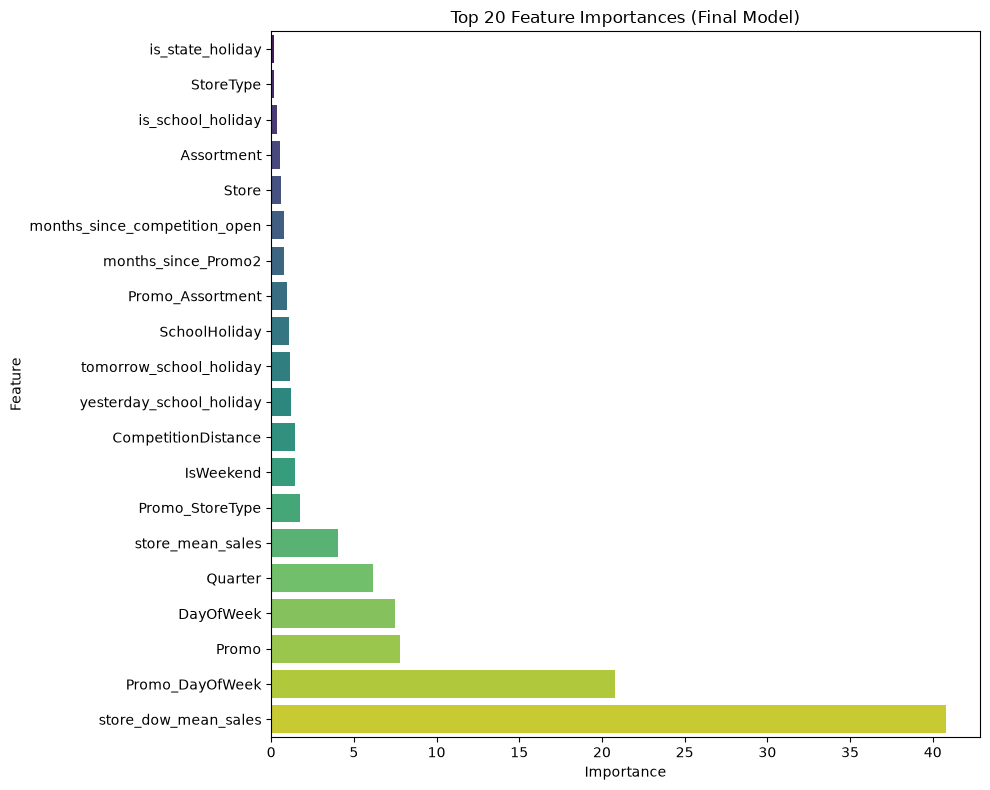

In [62]:
# Plot
top_n = 20
plot_df = imp_df_cb.head(top_n).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 20 Feature Importances (Final Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 9.1. Hyperparameter tuning with Optuna for LightGBM

In [63]:
mask_valid_open = (valid_part_eng['Open'] == 1).values

def rmspe_lgb(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    mask = y_true != 0
    score = np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))
    return 'rmspe', score, False

def objective_lgb_full(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 1e-3, 5.0, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_eng, y_train_eng_log,
        eval_set=[(X_valid_eng[mask_valid_open], y_valid_eng_log)],
        eval_metric=rmspe_lgb,
        callbacks=[lgb.early_stopping(30)]
    )

    pred = np.zeros(len(X_valid_eng))
    pred[mask_valid_open] = np.expm1(model.predict(X_valid_eng[mask_valid_open]))
    pred = np.maximum(pred, 0)

    return rmspe(y_valid_eng, pred)

In [64]:
sampler = optuna.samplers.TPESampler(seed=42, n_startup_trials=5)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)
study_lgb = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)

study_lgb.optimize(objective_lgb_full, n_trials=25, show_progress_bar=True)

print('Best params for LightGBM:', study_lgb.best_params)
print('Best RMSPE for LightGBM:', study_lgb.best_value)

[I 2026-07-29 18:07:19,734] A new study created in memory with name: no-name-6a677322-9b35-4af5-853b-e94638e24a74
  0%|                                                                                                                                                   | 0/25 [00:00<?, ?it/s]

Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[562]	valid_0's l2: 0.0260843	valid_0's rmspe: 0.0180185


Best trial: 0. Best value: 0.165084:   4%|████                                                                                                  | 1/25 [00:17<06:50, 17.12s/it]

[I 2026-07-29 18:07:36,860] Trial 0 finished with value: 0.1650842180923468 and parameters: {'n_estimators': 562, 'learning_rate': 0.09237421878009823, 'num_leaves': 76, 'max_depth': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044, 'min_child_samples': 20, 'min_sum_hessian_in_leaf': 0.4160439645256604, 'feature_fraction': 0.608233797718321, 'feature_fraction_bynode': 0.9879639408647978}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[882]	valid_0's l2: 0.0272848	valid_0's rmspe: 0.0184507


Best trial: 0. Best value: 0.165084:   8%|████████▏                                                                                             | 2/25 [00:37<07:20, 19.13s/it]

[I 2026-07-29 18:07:57,402] Trial 1 finished with value: 0.16892858141573427 and parameters: {'n_estimators': 883, 'learning_rate': 0.02814807274769496, 'num_leaves': 26, 'max_depth': 4, 'subsample': 0.7216968971838151, 'colsample_bytree': 0.8099025726528951, 'reg_alpha': 0.039605150456850806, 'reg_lambda': 0.011946697137851393, 'min_child_samples': 20, 'min_sum_hessian_in_leaf': 0.003280829084730048, 'feature_fraction': 0.7168578594140873, 'feature_fraction_bynode': 0.7465447373174767}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[616]	valid_0's l2: 0.0263298	valid_0's rmspe: 0.0181053


Best trial: 0. Best value: 0.165084:  12%|████████████▏                                                                                         | 3/25 [00:51<06:06, 16.68s/it]

[I 2026-07-29 18:08:11,164] Trial 2 finished with value: 0.16627729189763057 and parameters: {'n_estimators': 619, 'learning_rate': 0.07076922519051031, 'num_leaves': 28, 'max_depth': 6, 'subsample': 0.836965827544817, 'colsample_bytree': 0.6185801650879991, 'reg_alpha': 0.1767218232266506, 'reg_lambda': 0.0042733023193754, 'min_child_samples': 6, 'min_sum_hessian_in_leaf': 3.235185145617431, 'feature_fraction': 0.9862528132298237, 'feature_fraction_bynode': 0.9233589392465844}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[513]	valid_0's l2: 0.0271297	valid_0's rmspe: 0.0183968


Best trial: 0. Best value: 0.165084:  16%|████████████████▎                                                                                     | 4/25 [01:06<05:35, 15.99s/it]

[I 2026-07-29 18:08:26,098] Trial 3 finished with value: 0.16874284192796132 and parameters: {'n_estimators': 513, 'learning_rate': 0.023404527272255594, 'num_leaves': 72, 'max_depth': 5, 'subsample': 0.6488152939379115, 'colsample_bytree': 0.798070764044508, 'reg_alpha': 0.0013403002793227008, 'reg_lambda': 2.3096644596472733, 'min_child_samples': 11, 'min_sum_hessian_in_leaf': 0.282260467839396, 'feature_fraction': 0.7246844304357644, 'feature_fraction_bynode': 0.8080272084711243}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[683]	valid_0's l2: 0.0261644	valid_0's rmspe: 0.018046


Best trial: 0. Best value: 0.165084:  20%|████████████████████▍                                                                                 | 5/25 [01:31<06:27, 19.40s/it]

[I 2026-07-29 18:08:51,528] Trial 4 finished with value: 0.16564490282397915 and parameters: {'n_estimators': 683, 'learning_rate': 0.02693008444549291, 'num_leaves': 98, 'max_depth': 7, 'subsample': 0.9757995766256756, 'colsample_bytree': 0.9579309401710595, 'reg_alpha': 0.16278488880914346, 'reg_lambda': 2.570307853015558, 'min_child_samples': 7, 'min_sum_hessian_in_leaf': 0.005308046630775945, 'feature_fraction': 0.6180909155642152, 'feature_fraction_bynode': 0.7301321323053057}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[325]	valid_0's l2: 0.0261496	valid_0's rmspe: 0.0180458


Best trial: 0. Best value: 0.165084:  24%|████████████████████████▍                                                                             | 6/25 [01:43<05:17, 16.71s/it]

[I 2026-07-29 18:09:03,038] Trial 5 finished with value: 0.16576863536925174 and parameters: {'n_estimators': 325, 'learning_rate': 0.08549839850760381, 'num_leaves': 60, 'max_depth': 8, 'subsample': 0.8282610725789175, 'colsample_bytree': 0.6154900799844732, 'reg_alpha': 3.549467469717634, 'reg_lambda': 0.08137067905888042, 'min_child_samples': 29, 'min_sum_hessian_in_leaf': 0.08868460120238117, 'feature_fraction': 0.9784423295876755, 'feature_fraction_bynode': 0.6081629379213616}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[932]	valid_0's l2: 0.0276639	valid_0's rmspe: 0.0185802


Best trial: 0. Best value: 0.165084:  28%|████████████████████████████▌                                                                         | 7/25 [02:04<05:25, 18.07s/it]

[I 2026-07-29 18:09:23,882] Trial 6 finished with value: 0.16943832202235684 and parameters: {'n_estimators': 941, 'learning_rate': 0.04895837253698802, 'num_leaves': 100, 'max_depth': 3, 'subsample': 0.6064534727802704, 'colsample_bytree': 0.9981964328802695, 'reg_alpha': 0.0011005668804774911, 'reg_lambda': 0.2070343031495586, 'min_child_samples': 19, 'min_sum_hessian_in_leaf': 4.915552734563408, 'feature_fraction': 0.8436295453734979, 'feature_fraction_bynode': 0.9487487243485925}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[334]	valid_0's l2: 0.0276799	valid_0's rmspe: 0.0185999


Best trial: 0. Best value: 0.165084:  32%|████████████████████████████████▋                                                                     | 8/25 [02:13<04:19, 15.28s/it]

[I 2026-07-29 18:09:33,210] Trial 7 finished with value: 0.170680823200322 and parameters: {'n_estimators': 334, 'learning_rate': 0.04290810793571099, 'num_leaves': 10, 'max_depth': 8, 'subsample': 0.9869745933861575, 'colsample_bytree': 0.7603911751833413, 'reg_alpha': 4.972922419021308, 'reg_lambda': 0.0010966794704979853, 'min_child_samples': 27, 'min_sum_hessian_in_leaf': 0.047120772511269296, 'feature_fraction': 0.8752918047800797, 'feature_fraction_bynode': 0.9985642153294363}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[811]	valid_0's l2: 0.0260655	valid_0's rmspe: 0.0180113


Best trial: 0. Best value: 0.165084:  36%|████████████████████████████████████▋                                                                 | 9/25 [02:38<04:55, 18.46s/it]

[I 2026-07-29 18:09:58,657] Trial 8 finished with value: 0.165235383751656 and parameters: {'n_estimators': 811, 'learning_rate': 0.05734440880346216, 'num_leaves': 63, 'max_depth': 6, 'subsample': 0.8051705348475134, 'colsample_bytree': 0.8887861611939726, 'reg_alpha': 0.03133866042395561, 'reg_lambda': 0.2131331374221804, 'min_child_samples': 16, 'min_sum_hessian_in_leaf': 0.6377440506957677, 'feature_fraction': 0.6119077439312612, 'feature_fraction_bynode': 0.6031100727781092}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[474]	valid_0's l2: 0.02814	valid_0's rmspe: 0.0187562


Best trial: 0. Best value: 0.165084:  40%|████████████████████████████████████████▍                                                            | 10/25 [02:49<03:58, 15.92s/it]

[I 2026-07-29 18:10:08,897] Trial 9 finished with value: 0.17189695339650568 and parameters: {'n_estimators': 474, 'learning_rate': 0.03685647956274559, 'num_leaves': 46, 'max_depth': 3, 'subsample': 0.9044243675990947, 'colsample_bytree': 0.7133608006125414, 'reg_alpha': 0.01065521400779512, 'reg_lambda': 0.0348758656384653, 'min_child_samples': 24, 'min_sum_hessian_in_leaf': 0.0010751809437107224, 'feature_fraction': 0.7726044389806279, 'feature_fraction_bynode': 0.8534341144197607}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[760]	valid_0's l2: 0.0262469	valid_0's rmspe: 0.0180789


Best trial: 0. Best value: 0.165084:  44%|████████████████████████████████████████████▍                                                        | 11/25 [03:08<03:57, 16.95s/it]

[I 2026-07-29 18:10:28,178] Trial 10 finished with value: 0.16583616409404298 and parameters: {'n_estimators': 760, 'learning_rate': 0.09705968495553342, 'num_leaves': 80, 'max_depth': 5, 'subsample': 0.7065156005441935, 'colsample_bytree': 0.6875357143589806, 'reg_alpha': 0.8496121692960077, 'reg_lambda': 0.49998500059074563, 'min_child_samples': 13, 'min_sum_hessian_in_leaf': 0.015308303782855234, 'feature_fraction': 0.9025235002521843, 'feature_fraction_bynode': 0.7057900127572265}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[811]	valid_0's l2: 0.026137	valid_0's rmspe: 0.0180356


Best trial: 0. Best value: 0.165084:  48%|████████████████████████████████████████████████▍                                                    | 12/25 [03:34<04:15, 19.64s/it]

[I 2026-07-29 18:10:53,983] Trial 11 finished with value: 0.16528248900230955 and parameters: {'n_estimators': 811, 'learning_rate': 0.06124999582068792, 'num_leaves': 60, 'max_depth': 6, 'subsample': 0.7347841536787402, 'colsample_bytree': 0.898455323922507, 'reg_alpha': 0.007371802765387095, 'reg_lambda': 0.4531208634209338, 'min_child_samples': 17, 'min_sum_hessian_in_leaf': 0.6401522561093029, 'feature_fraction': 0.6038342553981939, 'feature_fraction_bynode': 0.6192918962286043}. Best is trial 0 with value: 0.1650842180923468.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[791]	valid_0's l2: 0.0260653	valid_0's rmspe: 0.018011


Best trial: 12. Best value: 0.165061:  52%|████████████████████████████████████████████████████                                                | 13/25 [04:03<04:29, 22.42s/it]

[I 2026-07-29 18:11:22,799] Trial 12 finished with value: 0.16506094968682583 and parameters: {'n_estimators': 994, 'learning_rate': 0.06458071026149048, 'num_leaves': 82, 'max_depth': 6, 'subsample': 0.7857793785803378, 'colsample_bytree': 0.8868816496924848, 'reg_alpha': 0.007002701190954434, 'reg_lambda': 4.778926332401927, 'min_child_samples': 15, 'min_sum_hessian_in_leaf': 0.7593568118133716, 'feature_fraction': 0.6640028758389271, 'feature_fraction_bynode': 0.8513412900817721}. Best is trial 12 with value: 0.16506094968682583.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[687]	valid_0's l2: 0.0259889	valid_0's rmspe: 0.0179832


Best trial: 13. Best value: 0.164816:  56%|████████████████████████████████████████████████████████                                            | 14/25 [04:25<04:07, 22.46s/it]

[I 2026-07-29 18:11:45,346] Trial 13 finished with value: 0.16481633492694325 and parameters: {'n_estimators': 960, 'learning_rate': 0.07695225834742318, 'num_leaves': 86, 'max_depth': 7, 'subsample': 0.7656507987029817, 'colsample_bytree': 0.8653339593695218, 'reg_alpha': 0.0038802671427549413, 'reg_lambda': 4.701065366817464, 'min_child_samples': 23, 'min_sum_hessian_in_leaf': 1.3140832749119467, 'feature_fraction': 0.6730086770800943, 'feature_fraction_bynode': 0.8773072820518931}. Best is trial 13 with value: 0.16481633492694325.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[549]	valid_0's l2: 0.0259824	valid_0's rmspe: 0.0179816


Best trial: 13. Best value: 0.164816:  60%|████████████████████████████████████████████████████████████                                        | 15/25 [04:45<03:37, 21.79s/it]

[I 2026-07-29 18:12:05,597] Trial 14 finished with value: 0.1649868573108734 and parameters: {'n_estimators': 961, 'learning_rate': 0.07010040063323915, 'num_leaves': 90, 'max_depth': 7, 'subsample': 0.7767528172041664, 'colsample_bytree': 0.8722117463955862, 'reg_alpha': 0.007769101371202856, 'reg_lambda': 4.893402908615673, 'min_child_samples': 24, 'min_sum_hessian_in_leaf': 1.6728512060785756, 'feature_fraction': 0.6792345108034201, 'feature_fraction_bynode': 0.8672335505971372}. Best is trial 13 with value: 0.16481633492694325.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[749]	valid_0's l2: 0.0259155	valid_0's rmspe: 0.0179568


Best trial: 15. Best value: 0.164488:  64%|████████████████████████████████████████████████████████████████                                    | 16/25 [05:10<03:24, 22.67s/it]

[I 2026-07-29 18:12:30,304] Trial 15 finished with value: 0.16448754300799398 and parameters: {'n_estimators': 1000, 'learning_rate': 0.07450191924978058, 'num_leaves': 84, 'max_depth': 7, 'subsample': 0.9029259064573444, 'colsample_bytree': 0.8433320431450579, 'reg_alpha': 0.0038355000401713675, 'reg_lambda': 1.0514011424398708, 'min_child_samples': 24, 'min_sum_hessian_in_leaf': 1.9203794996044603, 'feature_fraction': 0.70270101883663, 'feature_fraction_bynode': 0.8864932256799045}. Best is trial 15 with value: 0.16448754300799398.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[574]	valid_0's l2: 0.0259493	valid_0's rmspe: 0.01797


Best trial: 15. Best value: 0.164488:  68%|████████████████████████████████████████████████████████████████████                                | 17/25 [05:29<02:52, 21.61s/it]

[I 2026-07-29 18:12:49,444] Trial 16 finished with value: 0.16464515234761143 and parameters: {'n_estimators': 883, 'learning_rate': 0.07978544000604662, 'num_leaves': 89, 'max_depth': 7, 'subsample': 0.8859928626506205, 'colsample_bytree': 0.8328225082152066, 'reg_alpha': 0.003480540658143116, 'reg_lambda': 0.8590907863129358, 'min_child_samples': 24, 'min_sum_hessian_in_leaf': 1.9003376355853212, 'feature_fraction': 0.7803540887136295, 'feature_fraction_bynode': 0.8958715473744392}. Best is trial 15 with value: 0.16448754300799398.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[880]	valid_0's l2: 0.0258668	valid_0's rmspe: 0.0179403


Best trial: 17. Best value: 0.164429:  72%|████████████████████████████████████████████████████████████████████████                            | 18/25 [05:53<02:35, 22.20s/it]

[I 2026-07-29 18:13:13,028] Trial 17 finished with value: 0.164429255449201 and parameters: {'n_estimators': 882, 'learning_rate': 0.05445513004344585, 'num_leaves': 69, 'max_depth': 8, 'subsample': 0.8960567409919323, 'colsample_bytree': 0.8160377604636654, 'reg_alpha': 0.038133538413825496, 'reg_lambda': 0.8400136287496421, 'min_child_samples': 28, 'min_sum_hessian_in_leaf': 0.1659467281766542, 'feature_fraction': 0.7846780493863432, 'feature_fraction_bynode': 0.9155809755438369}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[845]	valid_0's l2: 0.0260179	valid_0's rmspe: 0.0179942


Best trial: 17. Best value: 0.164429:  76%|████████████████████████████████████████████████████████████████████████████                        | 19/25 [06:16<02:15, 22.63s/it]

[I 2026-07-29 18:13:36,651] Trial 18 finished with value: 0.1650054442140737 and parameters: {'n_estimators': 874, 'learning_rate': 0.04777080819929495, 'num_leaves': 50, 'max_depth': 8, 'subsample': 0.9332659633477832, 'colsample_bytree': 0.7487906159422062, 'reg_alpha': 0.029639162648748652, 'reg_lambda': 0.11487135066546826, 'min_child_samples': 30, 'min_sum_hessian_in_leaf': 0.1643725971484592, 'feature_fraction': 0.7889417776190656, 'feature_fraction_bynode': 0.8044643847601181}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[772]	valid_0's l2: 0.0260764	valid_0's rmspe: 0.0180179


Best trial: 17. Best value: 0.164429:  80%|████████████████████████████████████████████████████████████████████████████████                    | 20/25 [06:38<01:52, 22.42s/it]

[I 2026-07-29 18:13:58,583] Trial 19 finished with value: 0.1655462941507922 and parameters: {'n_estimators': 775, 'learning_rate': 0.03736563222398157, 'num_leaves': 68, 'max_depth': 8, 'subsample': 0.8843584601639288, 'colsample_bytree': 0.9328321740215862, 'reg_alpha': 0.1349487722262919, 'reg_lambda': 0.8114641775811026, 'min_child_samples': 27, 'min_sum_hessian_in_leaf': 0.04787980662955067, 'feature_fraction': 0.8289218484957821, 'feature_fraction_bynode': 0.954602488473346}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[683]	valid_0's l2: 0.0261968	valid_0's rmspe: 0.0180605


Best trial: 17. Best value: 0.164429:  84%|████████████████████████████████████████████████████████████████████████████████████                | 21/25 [06:57<01:25, 21.36s/it]

[I 2026-07-29 18:14:17,460] Trial 20 finished with value: 0.16573251258851301 and parameters: {'n_estimators': 686, 'learning_rate': 0.052643848229964214, 'num_leaves': 46, 'max_depth': 7, 'subsample': 0.9415025604559947, 'colsample_bytree': 0.7622978430480736, 'reg_alpha': 0.0773703795717597, 'reg_lambda': 0.036683098768124374, 'min_child_samples': 26, 'min_sum_hessian_in_leaf': 0.14541841408989922, 'feature_fraction': 0.7450929510194209, 'feature_fraction_bynode': 0.913582753560175}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[497]	valid_0's l2: 0.0259711	valid_0's rmspe: 0.0179765


Best trial: 17. Best value: 0.164429:  88%|████████████████████████████████████████████████████████████████████████████████████████            | 22/25 [07:16<01:01, 20.54s/it]

[I 2026-07-29 18:14:36,086] Trial 21 finished with value: 0.16469520910193844 and parameters: {'n_estimators': 885, 'learning_rate': 0.08082426510863343, 'num_leaves': 94, 'max_depth': 7, 'subsample': 0.868626237148764, 'colsample_bytree': 0.8266957040825574, 'reg_alpha': 0.002834269193678527, 'reg_lambda': 0.7290243775300562, 'min_child_samples': 22, 'min_sum_hessian_in_leaf': 1.323075605858707, 'feature_fraction': 0.7915215072702328, 'feature_fraction_bynode': 0.903274014401569}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[536]	valid_0's l2: 0.0259355	valid_0's rmspe: 0.0179659


Best trial: 17. Best value: 0.164429:  92%|████████████████████████████████████████████████████████████████████████████████████████████        | 23/25 [07:36<00:41, 20.56s/it]

[I 2026-07-29 18:14:56,684] Trial 22 finished with value: 0.16453204032023735 and parameters: {'n_estimators': 900, 'learning_rate': 0.07304981735000814, 'num_leaves': 87, 'max_depth': 8, 'subsample': 0.92327497177076, 'colsample_bytree': 0.8318570339988645, 'reg_alpha': 0.015654305305451435, 'reg_lambda': 0.93567538125646, 'min_child_samples': 25, 'min_sum_hessian_in_leaf': 2.3217909848145113, 'feature_fraction': 0.8239306524275616, 'feature_fraction_bynode': 0.7954280407734814}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[836]	valid_0's l2: 0.0259221	valid_0's rmspe: 0.0179608


Best trial: 17. Best value: 0.164429:  96%|████████████████████████████████████████████████████████████████████████████████████████████████    | 24/25 [08:03<00:22, 22.35s/it]

[I 2026-07-29 18:15:23,235] Trial 23 finished with value: 0.1644993755141542 and parameters: {'n_estimators': 844, 'learning_rate': 0.05801784625964913, 'num_leaves': 74, 'max_depth': 8, 'subsample': 0.9477594181013996, 'colsample_bytree': 0.84389955089583, 'reg_alpha': 0.014797734954951293, 'reg_lambda': 1.5258802641897298, 'min_child_samples': 27, 'min_sum_hessian_in_leaf': 3.144895669376736, 'feature_fraction': 0.9254708381497683, 'feature_fraction_bynode': 0.813044643914557}. Best is trial 17 with value: 0.164429255449201.
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[798]	valid_0's l2: 0.0259103	valid_0's rmspe: 0.0179568


Best trial: 17. Best value: 0.164429: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [08:27<00:00, 20.29s/it]

[I 2026-07-29 18:15:46,892] Trial 24 finished with value: 0.16457585071965194 and parameters: {'n_estimators': 838, 'learning_rate': 0.05629648420519924, 'num_leaves': 70, 'max_depth': 8, 'subsample': 0.9529764545305257, 'colsample_bytree': 0.7876956102343837, 'reg_alpha': 0.014752851811410216, 'reg_lambda': 0.31168999042512346, 'min_child_samples': 28, 'min_sum_hessian_in_leaf': 4.103311959421273, 'feature_fraction': 0.9401050914747211, 'feature_fraction_bynode': 0.8210829542046517}. Best is trial 17 with value: 0.164429255449201.
Best params for LightGBM: {'n_estimators': 882, 'learning_rate': 0.05445513004344585, 'num_leaves': 69, 'max_depth': 8, 'subsample': 0.8960567409919323, 'colsample_bytree': 0.8160377604636654, 'reg_alpha': 0.038133538413825496, 'reg_lambda': 0.8400136287496421, 'min_child_samples': 28, 'min_sum_hessian_in_leaf': 0.1659467281766542, 'feature_fraction': 0.7846780493863432, 'feature_fraction_bynode': 0.9155809755438369}
Best RMSPE for LightGBM: 0.16442925544920

In [65]:
print("Best trial LGB:")
best_trial = study_lgb.best_trial
print(f"  RMSPE: {best_trial.value:.6f}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

Best trial LGB:
  RMSPE: 0.164429
  Params:
    n_estimators: 882
    learning_rate: 0.05445513004344585
    num_leaves: 69
    max_depth: 8
    subsample: 0.8960567409919323
    colsample_bytree: 0.8160377604636654
    reg_alpha: 0.038133538413825496
    reg_lambda: 0.8400136287496421
    min_child_samples: 28
    min_sum_hessian_in_leaf: 0.1659467281766542
    feature_fraction: 0.7846780493863432
    feature_fraction_bynode: 0.9155809755438369


## 9.2. Final LightGBM Model with Optimal Parameters

In [66]:
best_params_lgb = study_lgb.best_params
best_params_lgb['random_state'] = 42
best_params_lgb['n_jobs'] = -1
best_params_lgb['verbosity'] = -1

final_model_lgb = lgb.LGBMRegressor(**best_params_lgb)

final_model_lgb.fit(
    X_train_eng, y_train_eng_log,
    eval_set=[(X_valid_eng[mask_valid_open], y_valid_eng_log)],
    eval_metric=rmspe_lgb,
    callbacks=[lgb.early_stopping(50)]
)

pred_final_lgb = np.zeros(len(X_valid_eng))
pred_final_lgb[mask_valid_open] = np.expm1(final_model_lgb.predict(X_valid_eng[mask_valid_open]))
pred_final_lgb = np.maximum(pred_final_lgb, 0)

final_score_lgb = rmspe(y_valid_eng, pred_final_lgb)
print(f"Final LightGBM RMSPE on validation: {final_score_lgb:.6f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[880]	valid_0's l2: 0.0258668	valid_0's rmspe: 0.0179403
Final LightGBM RMSPE on validation: 0.164429


## 9.3. Feature Importance for LightGBM

In [67]:
importance = final_model_lgb.feature_importances_
feature_names = X_train_eng.columns
imp_df_lgb = pd.DataFrame({'feature': feature_names, 'importance': importance})
imp_df_lgb = imp_df_lgb.sort_values('importance', ascending=False).reset_index(drop=True)
imp_df_lgb['importance_pct'] = imp_df_lgb['importance'] / imp_df_lgb['importance'].sum() * 100

print("Top 20 features:")
print(imp_df_lgb.head(30).to_string(index=False))

Top 20 features:
                      feature  importance  importance_pct
          CompetitionDistance        7380       12.332888
             store_mean_sales        7133       11.920120
                        Store        6192       10.347594
         store_dow_mean_sales        5663        9.463570
                      Quarter        5360        8.957219
months_since_competition_open        4267        7.130682
                    DayOfWeek        3702        6.186497
          months_since_Promo2        3420        5.715241
              Promo_StoreType        2910        4.862968
             Promo_Assortment        1928        3.221925
     yesterday_school_holiday        1768        2.954545
                SchoolHoliday        1643        2.745655
      tomorrow_school_holiday        1613        2.695521
              Promo_DayOfWeek        1189        1.986965
                    StoreType         934        1.560829
                        Promo         865        1.4455

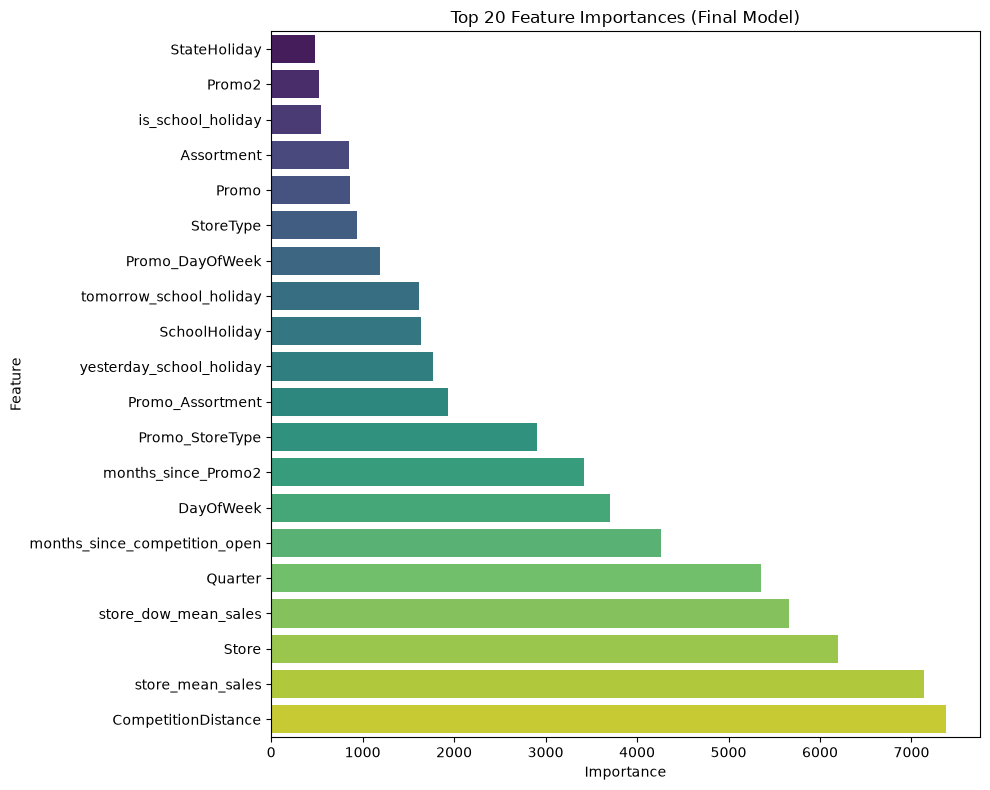

In [68]:
# Plot
top_n = 20
plot_df = imp_df_lgb.head(top_n).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x='importance', y='feature', hue='feature', palette='viridis', legend=False)
plt.title('Top 20 Feature Importances (Final Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 10.1. Try ansemble of LGB models

In [69]:
preds_lgb = []
models_lgb = []
seeds = [42, 123, 456, 789, 1010]

for seed in seeds:
    seed_params = best_params_lgb.copy()
    seed_params['random_state'] = seed

    model = lgb.LGBMRegressor(**seed_params)
    model.fit(
        X_train_eng, y_train_eng_log,
        eval_set=[(X_valid_eng[mask_valid_open], y_valid_eng_log)],
        eval_metric=rmspe_lgb,
        callbacks=[lgb.early_stopping(50)]
    )

    models_lgb.append(model)

    pred = np.zeros(len(X_valid_eng))
    pred[mask_valid_open] = np.expm1(model.predict(X_valid_eng[mask_valid_open]))
    preds_lgb.append(pred)

ensemble_pred_lgb = np.mean(preds_lgb, axis=0)
ensemble_pred_lgb = np.maximum(ensemble_pred_lgb, 0)
print(f"Ensemble RMSPE: {rmspe(y_valid_eng, ensemble_pred_lgb):.6f}")

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[880]	valid_0's l2: 0.0258668	valid_0's rmspe: 0.0179403
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[857]	valid_0's l2: 0.0258883	valid_0's rmspe: 0.017948
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[881]	valid_0's l2: 0.0258957	valid_0's rmspe: 0.0179491
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[882]	valid_0's l2: 0.0259371	valid_0's rmspe: 0.0179636
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[836]	valid_0's l2: 0.0258941	valid_0's rmspe: 0.0179499
Ensemble RMSPE: 0.164314


In [70]:
# Try ansemble with parameters from manual imporvement
tuned_params = {
    'n_estimators':2000,
    'learning_rate':0.05,
    'num_leaves':64,
    'subsample':0.8,
    'colsample_bytree':0.8,
    'random_state':42,
    'n_jobs':-1,
    'verbosity':-1
}

preds_lgb_tuned = []
models_lgb_tuned = []
seeds = [42, 123, 456, 789, 1010]

for seed in seeds:
    tuned_params['random_state'] = seed

    model = lgb.LGBMRegressor(**tuned_params)
    model.fit(
        X_train_eng, y_train_eng_log,
        eval_set=[(X_valid_eng[mask_valid_open], y_valid_eng_log)],
        eval_metric=rmspe_lgb,
        callbacks=[lgb.early_stopping(50)]
    )

    models_lgb_tuned.append(model)

    pred = np.zeros(len(X_valid_eng))
    pred[mask_valid_open] = np.expm1(model.predict(X_valid_eng[mask_valid_open]))
    preds_lgb_tuned.append(pred)

ensemble_pred_lgb_tuned = np.mean(preds_lgb, axis=0)
ensemble_pred_lgb_tuned = np.maximum(ensemble_pred_lgb, 0)
print(f"Ensemble RMSPE: {rmspe(y_valid_eng, ensemble_pred_lgb_tuned):.6f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1197]	valid_0's l2: 0.0258162	valid_0's rmspe: 0.0179182
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[551]	valid_0's l2: 0.02598	valid_0's rmspe: 0.0179791
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1384]	valid_0's l2: 0.0257798	valid_0's rmspe: 0.0179034
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1704]	valid_0's l2: 0.0257244	valid_0's rmspe: 0.0178842
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[770]	valid_0's l2: 0.025871	valid_0's rmspe: 0.0179416
Ensemble RMSPE: 0.164314


## 10.2. Try ansemble of СatBoost models

In [71]:
base_params = best_params_cb.copy()
base_params['task_type'] = 'CPU'
base_params['verbose'] = False
base_params['loss_function'] = 'RMSE'
base_params['eval_metric'] = RMSPEMetric()
base_params['use_best_model'] = True

n_models = 5
models_cb = []
preds_valid_cb = []

for i in range(n_models):
    seed = 42 + i * 10
    seed_params = base_params.copy()
    seed_params['random_seed'] = seed

    model = CatBoostRegressor(**seed_params)
    model.fit(
        X_train_open, y_train_open_log,
        eval_set=(X_valid_open, y_valid_open_log),
        cat_features=cat_cols_eng,
        early_stopping_rounds=50,
        verbose=False
    )
    models_cb.append(model)

    pred = np.zeros(len(X_valid_eng))
    pred[mask_valid_open] = np.expm1(model.predict(X_valid_open))
    preds_valid_cb.append(pred)

ensemble_pred_cb = np.mean(preds_valid_cb, axis=0)
ensemble_pred_cb = np.maximum(ensemble_pred_cb, 0)
print(f"CatBoost ensemble RMSPE: {rmspe(y_valid_eng, ensemble_pred_cb):.6f}")

CatBoost ensemble RMSPE: 0.165203


## 11. Save Results and Model

In [72]:
models = models_lgb

# Feature importances are calculated as average for all models in ensemble
avg_importance = np.mean([model.feature_importances_ for model in models], axis=0)

# Dataframe with importnaces
imp_ensemble_df = pd.DataFrame({
    'feature': X_train_eng.columns,
    'importance': avg_importance
})
imp_ensemble_df = imp_ensemble_df.sort_values('importance', ascending=False).reset_index(drop=True)
imp_ensemble_df['importance_pct'] = imp_ensemble_df['importance'] / imp_ensemble_df['importance'].sum() * 100

In [73]:
imp_ensemble_df

,feature,importance,importance_pct
0,CompetitionDistance,7348.0,12.460742
1,store_mean_sales,6783.2,11.502954
2,Store,6173.2,10.468516
3,store_dow_mean_sales,5646.8,9.575846
4,Quarter,5359.4,9.088473
5,months_since_competition_open,4123.8,6.993142
6,DayOfWeek,3784.2,6.417248
7,months_since_Promo2,3236.4,5.488289
8,Promo_StoreType,2831.4,4.801490
9,Promo_Assortment,1946.0,3.300028


In [74]:
# Save importances table
imp_ensemble_df.to_csv(DATA_DIR / 'ensemble_feature_importance.csv', index=False)

# Save models ensemble
joblib.dump(models, DATA_DIR / 'ensemble_models.pkl')

print("Ensemble feature importance and models saved.")

Ensemble feature importance and models saved.


## 12. Predictions for test data

In [75]:
mask_test_open = (test_eng['Open'] == 1).values

preds_test = []
for model in models:
    pred = np.zeros(len(X_test_eng))
    pred[mask_test_open] = np.expm1(model.predict(X_test_eng[mask_test_open]))
    preds_test.append(pred)

ensemble_pred_test = np.mean(preds_test, axis=0)
ensemble_pred_test = np.maximum(ensemble_pred_test, 0)

ensemble_pred_test[~mask_test_open] = 0

In [76]:
# Create submission DataFrame
# Use 'Id' column from test set if exists, otherwise generate sequential IDs
if 'Id' in test_eng.columns:
    ids = test_eng['Id'].values
else:
    ids = np.arange(1, len(ensemble_pred_test) + 1)

submission = pd.DataFrame({
    'Id': ids,
    'Sales': ensemble_pred_test
})

In [77]:
# Save to CSV
submission.to_csv(DATA_DIR / 'submission.csv', index=False)
print("Submission file saved as submission.csv")

Submission file saved as submission.csv


## 13. Conclusion

**Feature engineering**

- Started from the cleaned Rossmann dataset with basic store, promo and competition information.
- Added calendar signals (Quarter, IsWeekend, state and school holiday flags, plus previous/next-day holiday indicators) to capture weekly and yearly seasonality.
- Created promo interaction features such as Promo × DayOfWeek, Promo × StoreType and Promo × Assortment to model heterogeneous promo effects across store types and days.
- Introduced two leakage-free historical aggregates computed only from the training period: `store_mean_sales` (per-store average sales) and `store_dow_mean_sales` (per-store, per-day-of-week average). These features later appeared among the most important predictors for tree-based models, confirming their value.

**Target transformation and validation**

- Transformed the target to `log1p(Sales)` to stabilize variance and make the RMSE training loss more consistent with the RMSPE evaluation metric.
- All models were trained on the log-transformed target and predictions were converted back with `expm1` before computing RMSPE.
- Validation used a time-based split on the full training period with an explicit mask for days when stores were open, aligning the offline metric with the competition’s evaluation logic.

**Modeling and optimization**

- Trained a baseline LightGBM model with engineered features, achieving a validation RMSPE of **0.1638**.
- Manually tuned key LightGBM hyperparameters (number of estimators, learning rate, number of leaves, subsample and colsample) and used early stopping with the custom RMSPE metric, improving validation RMSPE to **0.1636**.
- Trained a baseline CatBoost model with the same feature set and a custom RMSPE metric, obtaining a validation RMSPE of **0.1660**, slightly worse than LightGBM.
- Applied Optuna to tune CatBoost hyperparameters (iterations, learning rate, depth, L2 regularization, minimum data in leaf, border count) on a sampled subset of open-store records. The final tuned CatBoost model reached a validation RMSPE of **0.1655**, improving over the initial CatBoost baseline but still behind LightGBM.

**Ensembling and final setup**

- Built 5-seed bagging ensembles for both LightGBM and CatBoost by varying the random seed while keeping tuned hyperparameters fixed, then averaging predictions over all seeds.
- The LightGBM ensemble achieved the best validation performance and was chosen as the final model for generating test predictions and the competition submission.
- Feature importance analysis showed that `store_dow_mean_sales`, `store_mean_sales`, promo-related interactions and calendar variables dominate the models’ decisions, indicating that the final solution relies on meaningful, robust patterns rather than fragile shortcuts.
- The final submission based on the LightGBM ensemble achieved a private Kaggle score of **0.14864 RMSPE**, which is consistent with the offline validation level and confirms the stability of the modeling approach.